In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
print("Loading the Parquet masterpieces...")
train_df = pd.read_parquet("../data/model_ready/train_final.parquet")
valid_df = pd.read_parquet("../data/model_ready/valid_final.parquet")
test_df = pd.read_parquet("../data/model_ready/test_final.parquet")

# 1. Split into Features (X) and Target (y)
print("Splitting X and y...")
target_col = 'SalaryNormalized'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_valid = valid_df.drop(columns=[target_col])
y_valid = valid_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

#the values vary very much.. so log trainsforming them using log(1+ylabel) 
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)
y_test_log = np.log1p(y_test)

Loading the Parquet masterpieces...
Splitting X and y...


: 

In [ ]:
# 2. The God-Tier XGBoost Setup (GPU Accelerated)
print("Firing up the GPU for XGBoost...")
model = xgb.XGBRegressor(
    n_estimators=3000,        # Bumped it up
    learning_rate=0.03,       # Lowered it so it learns more carefully
    max_depth=15,              # Slightly deeper trees
    tree_method='hist',
    device='cuda',            # Keep your RTX 4050 sweating
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=100
)


# 3. Train the Beast
print("Training... Don't touch your laptop.")
model.fit(
    X_train, y_train_log,
    eval_set=[(X_train, y_train_log), (X_valid, y_valid_log)],    
    verbose=20               # Prints an update every 20 trees
)

## 



Firing up the GPU for XGBoost...
Training... Don't touch your laptop.


In [ ]:
# 4. Predict on the Test Set
print("Predicting on the Test Data...")
y_pred_log = model.predict(X_test)

#REVERSE the log transformation
# expm1 reverses log1p
y_pred_real = np.expm1(y_pred_log)
# 5. Flex the Metrics
mae = mean_absolute_error(y_test, y_pred_real)
r2 = r2_score(y_test, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_real))

print("\n" + "="*30)
print("🚀 NEW SUPERCHARGED RESULTS 🚀")
print("="*30)
print(f"R2 Score: {r2:.4f}")
print(f"MAE:      £{mae:.2f}")
print(f"RMSE:     £{rmse:.2f}")
print("="*30 + "\n")

Predicting on the Test Data...


c:\Users\nishk\anaconda3\envs\torch_gpu\Lib\site-packages\xgboost\core.py:774: UserWarning: [03:26:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



🚀 NEW SUPERCHARGED RESULTS 🚀
R2 Score: 0.6283
MAE:      £5376.66
RMSE:     £7358.48



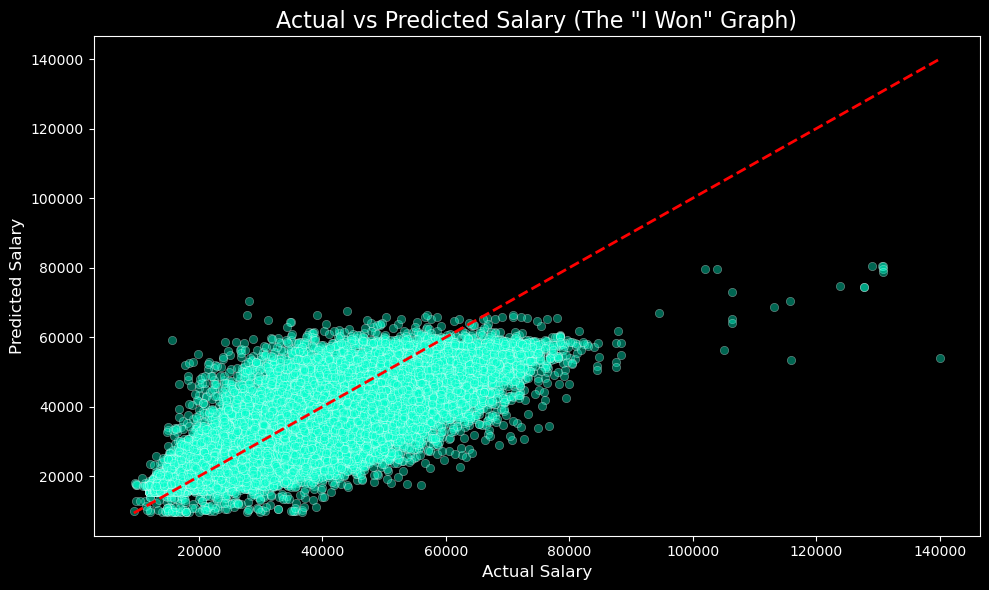

C:\Users\nishk\AppData\Local\Temp\ipykernel_23800\1177468274.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


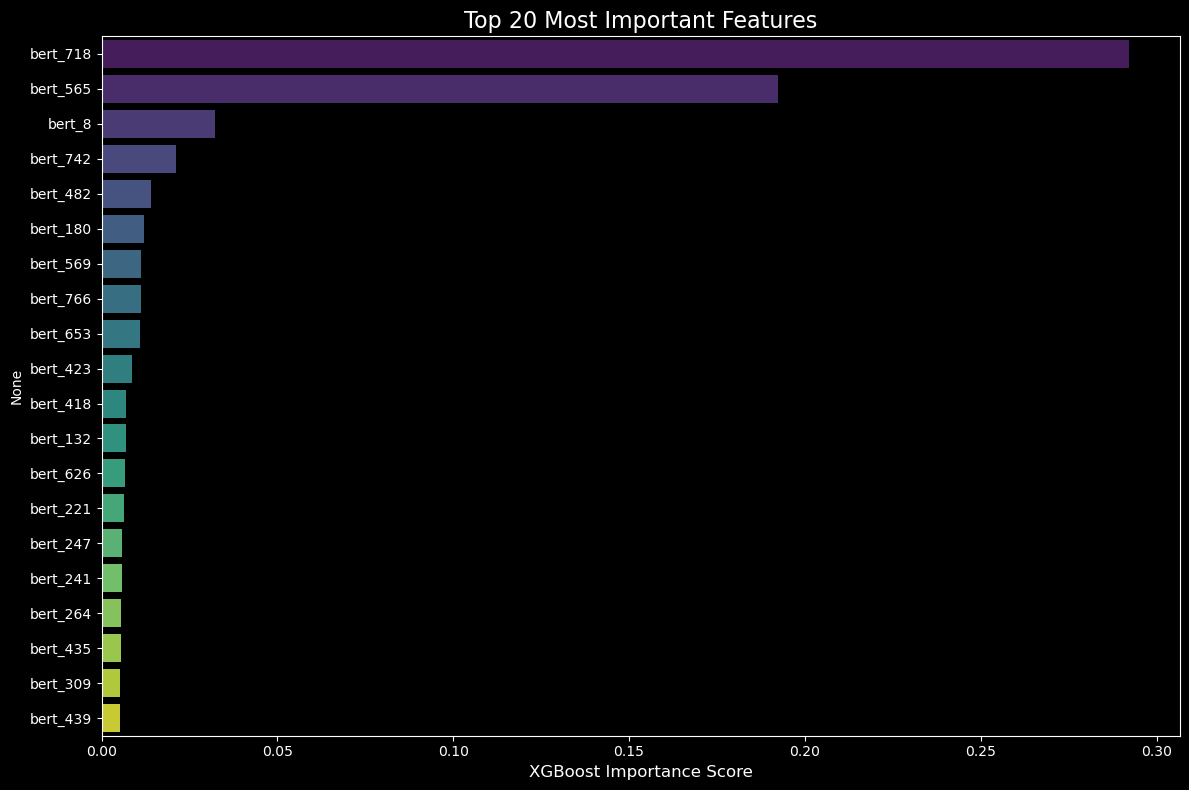

Graphs saved. Code executed. Victory secured.


In [ ]:
# 6. Make the Graphs to Flex in Class
plt.style.use('dark_background') # Because light mode is a crime

# Graph 1: Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_real, alpha=0.4, color='#00ffcc')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # The perfect line
plt.title('Actual vs Predicted Salary (The "I Won" Graph)', fontsize=16)
plt.xlabel('Actual Salary', fontsize=12)
plt.ylabel('Predicted Salary', fontsize=12)
plt.tight_layout()
plt.savefig('../data/actual_vs_predicted.png')
plt.show()

# Graph 2: Feature Importance (Top 20)
plt.figure(figsize=(12, 8))
# Get the top 20 most important columns
importance = model.feature_importances_
top_indices = np.argsort(importance)[::-1][:20]
top_features = X_train.columns[top_indices]
top_scores = importance[top_indices]

sns.barplot(x=top_scores, y=top_features, palette='viridis')
plt.title('Top 20 Most Important Features', fontsize=16)
plt.xlabel('XGBoost Importance Score', fontsize=12)
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()

print("Graphs saved. Code executed. Victory secured.")